<a href="https://colab.research.google.com/github/souravk03/Machine-Learning-404/blob/main/Day_55_Schoastic_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

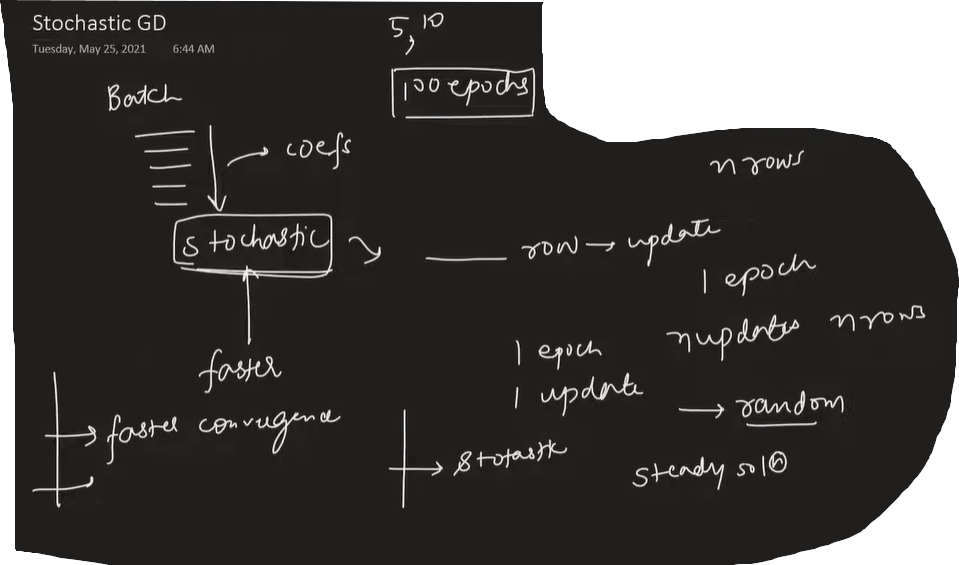

**New fomula for single random row selected for Schoastic gradient descent**

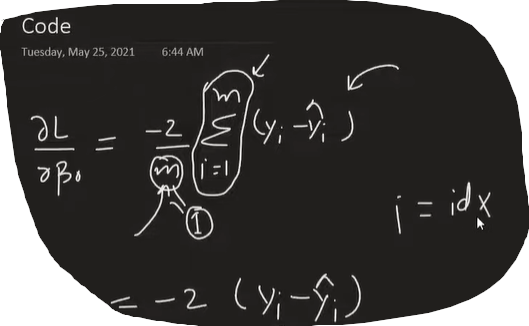

##**We will remove the submission as we are using SGD regressor in this we update the error based on single random row**

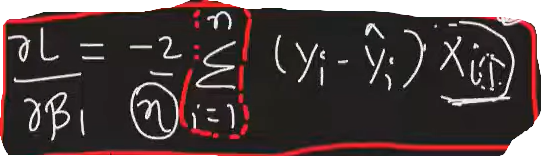

Time Comparison

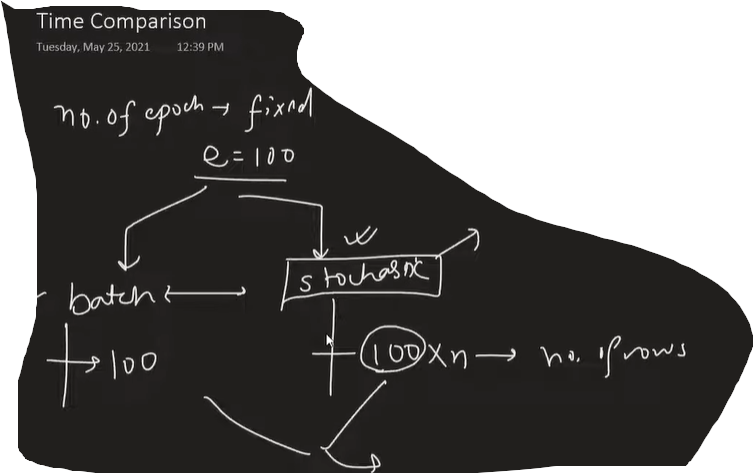

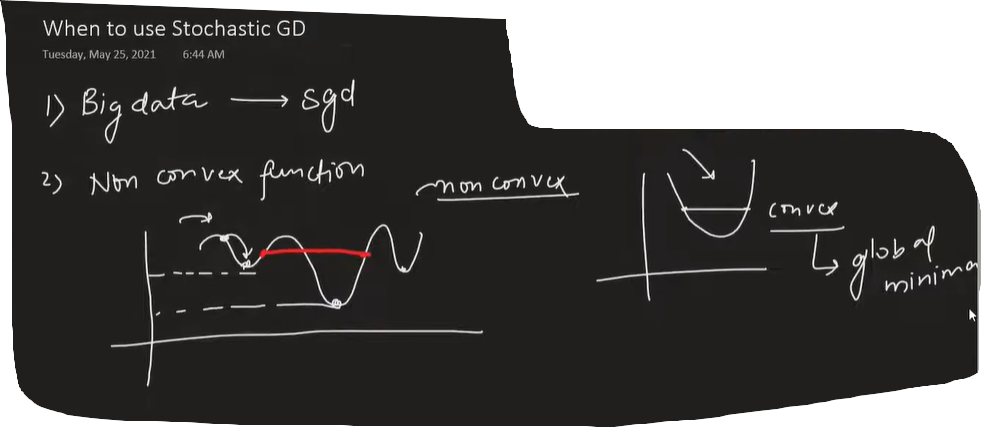

In [2]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import time
X,y = load_diabetes(return_X_y=True)
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [3]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
reg = LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [4]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [5]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4399338661568968

MY OWN CLASS FOR STOCHASTIC GRADIENT DESCET

In [1]:
class SGDRegressor:

    def __init__(self,learning_rate=0.01,epochs=100):

        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X_train,y_train):
        # init your coefs
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])

        for i in range(self.epochs):
            for j in range(X_train.shape[0]):
                idx = np.random.randint(0,X_train.shape[0])

                y_hat = np.dot(X_train[idx],self.coef_) + self.intercept_

                intercept_der = -2 * (y_train[idx] - y_hat)
                self.intercept_ = self.intercept_ - (self.lr * intercept_der)

                coef_der = -2 * np.dot((y_train[idx] - y_hat),X_train[idx])
                self.coef_ = self.coef_ - (self.lr * coef_der)

        print(self.intercept_,self.coef_)

    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [6]:
sgd = SGDRegressor(learning_rate=0.01,epochs=40)
start = time.time()
sgd.fit(X_train,y_train)
print("The time taken is",time.time() - start)

157.78775960982114 [  53.16950638  -49.4536413   307.3878188   224.14943847   26.87529132
  -14.26546726 -161.06205238  128.42057578  291.57221658  126.59546312]
The time taken is 0.5899109840393066


In [7]:
y_pred = sgd.predict(X_test)
r2_score(y_test,y_pred)

0.416672627480571

In [8]:
from sklearn.linear_model import SGDRegressor
reg = SGDRegressor(max_iter=100,learning_rate='constant',eta0=0.01)
reg.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


SGDRegressor(learning_rate='constant', max_iter=100)

In [9]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4322549475371035